In [2]:
import pandas as pd

columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root',
    'num_file_creations','num_shells','num_access_files',
    'num_outbound_cmds','is_host_login','is_guest_login',
    'count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate',
    'label','difficulty'
]

train_df = pd.read_csv("KDDTrain+.txt", names=columns)
test_df  = pd.read_csv("KDDTest+.txt", names=columns)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (125973, 43)
Test shape: (22544, 43)


In [3]:
# Step 1: Check label distribution
train_df['label'].value_counts().head(10)

,count
label,
normal,67343
neptune,41214
satan,3633
ipsweep,3599
portsweep,2931
smurf,2646
nmap,1493
back,956
teardrop,892


In [4]:
# Step 2: Binary classification (Normal vs Attack)
train_df['binary_label'] = train_df['label'].apply(
    lambda x: 0 if x == 'normal' else 1
)

train_df['binary_label'].value_counts()

,count
binary_label,
0,67343
1,58630


In [5]:
# Step 3: One-hot encode categorical features
categorical_cols = ['protocol_type', 'service', 'flag']

train_df_encoded = pd.get_dummies(
    train_df,
    columns=categorical_cols
)

print("Shape after encoding:", train_df_encoded.shape)

Shape after encoding: (125973, 125)


In [6]:
# Step 4: Separate features and target
X = train_df_encoded.drop(['label', 'binary_label', 'difficulty'], axis=1)
y = train_df_encoded['binary_label']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (125973, 122)
y shape: (125973,)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (100778, 122)
X_test: (25195, 122)
y_train: (100778,)
y_test: (25195,)


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape:", X_test_scaled.shape)

Scaled X_train shape: (100778, 122)
Scaled X_test shape: (25195, 122)


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Predictions
y_pred = log_reg.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9722960904941457

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.97     13469
           1       0.98      0.96      0.97     11726

    accuracy                           0.97     25195
   macro avg       0.97      0.97      0.97     25195
weighted avg       0.97      0.97      0.97     25195


Confusion Matrix:
 [[13199   270]
 [  428 11298]]


In [10]:
import numpy as np

# Convert to numpy arrays (sometimes they're already numpy)
X_train_cnn = np.array(X_train_scaled).reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn  = np.array(X_test_scaled).reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print("X_train_cnn:", X_train_cnn.shape)
print("X_test_cnn:", X_test_cnn.shape)

X_train_cnn: (100778, 122, 1)
X_test_cnn: (25195, 122, 1)


In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization

In [12]:
  model = Sequential()

# CNN layers
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(122, 1)))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

model.add(Conv1D(filters=32, kernel_size=3, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

# LSTM layer
model.add(LSTM(64))

# Dense layers
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

# Output layer (binary classification)
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 120, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 120, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 58, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 58, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 29, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,873 (140.13 KB)

 Trainable params: 35,681 (139.38 KB)

 Non-trainable params: 192 (768.00 B)

In [13]:
history = model.fit(
    X_train_cnn,
    y_train,
    epochs=5,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
315/315 ━━━━━━━━━━━━━━━━━━━━ 48s 141ms/step - accuracy: 0.9312 - loss: 0.2103 - val_accuracy: 0.5342 - val_loss: 1.8990
Epoch 2/5
315/315 ━━━━━━━━━━━━━━━━━━━━ 42s 132ms/step - accuracy: 0.9850 - loss: 0.0463 - val_accuracy: 0.8758 - val_loss: 0.3282
Epoch 3/5
315/315 ━━━━━━━━━━━━━━━━━━━━ 83s 136ms/step - accuracy: 0.9901 - loss: 0.0293 - val_accuracy: 0.9913 - val_loss: 0.0297
Epoch 4/5
315/315 ━━━━━━━━━━━━━━━━━━━━ 81s 133ms/step - accuracy: 0.9919 - loss: 0.0245 - val_accuracy: 0.9832 - val_loss: 0.0563
Epoch 5/5
315/315 ━━━━━━━━━━━━━━━━━━━━ 43s 136ms/step - accuracy: 0.9931 - loss: 0.0219 - val_accuracy: 0.9921 - val_loss: 0.0220


In [14]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_prob = model.predict(X_test_cnn)
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

788/788 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     13469
           1       0.99      1.00      0.99     11726

    accuracy                           0.99     25195
   macro avg       0.99      0.99      0.99     25195
weighted avg       0.99      0.99      0.99     25195

[[13316   153]
 [   47 11679]]


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np

# Predict probabilities → convert to 0/1
y_pred_prob = model.predict(X_test_cnn)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score  :", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

788/788 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step
Accuracy : 0.9920619170470332
Precision: 0.9870689655172413
Recall   : 0.9959918130649837
F1-score  : 0.9915103149673147

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99     13469
           1       0.99      1.00      0.99     11726

    accuracy                           0.99     25195
   macro avg       0.99      0.99      0.99     25195
weighted avg       0.99      0.99      0.99     25195


Confusion Matrix:
 [[13316   153]
 [   47 11679]]


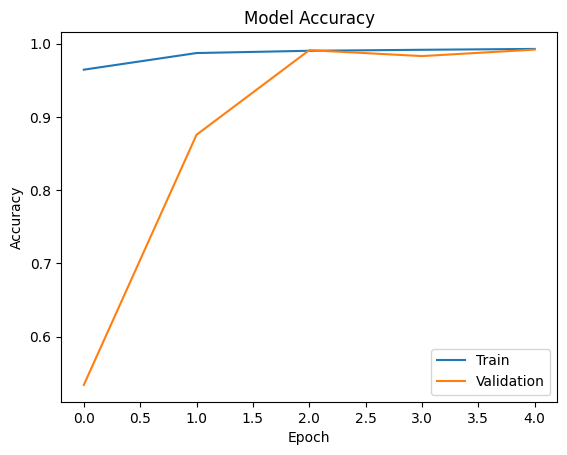

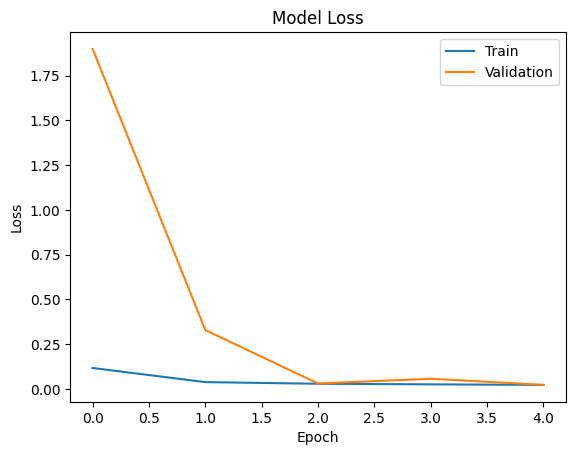

In [16]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [17]:

results = {
    "Model": ["Logistic Regression", "CNN-LSTM"],
    "Accuracy": [0.9722, accuracy_score(y_test, y_pred)],  # replace 0.9722 with your LR accuracy
}

import pandas as pd
pd.DataFrame(results)

,Model,Accuracy
0,Logistic Regression,0.972200
1,CNN-LSTM,0.992062


In [18]:
import numpy as np

# Make sure these exist from your earlier cells:
# X_train_scaled, X_test_scaled, y_train, y_test

X_train_scaled = np.asarray(X_train_scaled, dtype=np.float32)
X_test_scaled  = np.asarray(X_test_scaled, dtype=np.float32)
y_train = np.asarray(y_train, dtype=np.int32)
y_test  = np.asarray(y_test, dtype=np.int32)

# CNN/LSTM expects 3D: (samples, timesteps/features, channels)
X_train_seq = X_train_scaled[..., np.newaxis]   # (N, 122, 1)
X_test_seq  = X_test_scaled[..., np.newaxis]    # (N, 122, 1)

print("X_train_seq:", X_train_seq.shape)
print("X_test_seq :", X_test_seq.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)


X_train_seq: (100778, 122, 1)
X_test_seq : (25195, 122, 1)
y_train: (100778,) y_test: (25195,)


In [19]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

tf.random.set_seed(42)

model = models.Sequential([
    layers.Input(shape=(122, 1)),

    layers.Conv1D(64, kernel_size=3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),

    layers.Conv1D(32, kernel_size=3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),

    layers.LSTM(64),

    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 122, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 122, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 61, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 61, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 61, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,873 (140.13 KB)

 Trainable params: 35,681 (139.38 KB)

 Non-trainable params: 192 (768.00 B)

In [20]:
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train_seq, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 48s 139ms/step - accuracy: 0.9199 - loss: 0.2132 - val_accuracy: 0.6222 - val_loss: 0.5355
Epoch 2/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 45s 143ms/step - accuracy: 0.9883 - loss: 0.0344 - val_accuracy: 0.9903 - val_loss: 0.0315
Epoch 3/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 80s 137ms/step - accuracy: 0.9916 - loss: 0.0247 - val_accuracy: 0.9892 - val_loss: 0.0291
Epoch 4/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 47s 150ms/step - accuracy: 0.9931 - loss: 0.0218 - val_accuracy: 0.9931 - val_loss: 0.0214
Epoch 5/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 43s 137ms/step - accuracy: 0.9933 - loss: 0.0190 - val_accuracy: 0.9939 - val_loss: 0.0179
Epoch 6/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 82s 137ms/step - accuracy: 0.9946 - loss: 0.0172 - val_accuracy: 0.9931 - val_loss: 0.0202
Epoch 7/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 44s 140ms/step - accuracy: 0.9949 - loss: 0.0163 - val_accuracy: 0.9941 - val_loss: 0.0167
Epoch 8/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 43s 137ms/step - accuracy: 0.9951 - loss: 0

In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_prob = model.predict(X_test_seq).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


788/788 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step
Accuracy: 0.9944036515181583

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99     13469
           1       0.99      0.99      0.99     11726

    accuracy                           0.99     25195
   macro avg       0.99      0.99      0.99     25195
weighted avg       0.99      0.99      0.99     25195


Confusion Matrix:
 [[13389    80]
 [   61 11665]]


CNN-LSTM (Random Split) Accuracy: 0.9944036515181583

Classification Report:
               precision    recall  f1-score   support

           0     0.9955    0.9941    0.9948     13469
           1     0.9932    0.9948    0.9940     11726

    accuracy                         0.9944     25195
   macro avg     0.9943    0.9944    0.9944     25195
weighted avg     0.9944    0.9944    0.9944     25195


Confusion Matrix:
 [[13389    80]
 [   61 11665]]


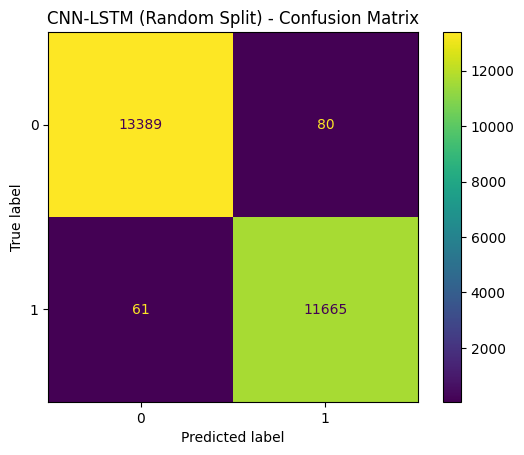

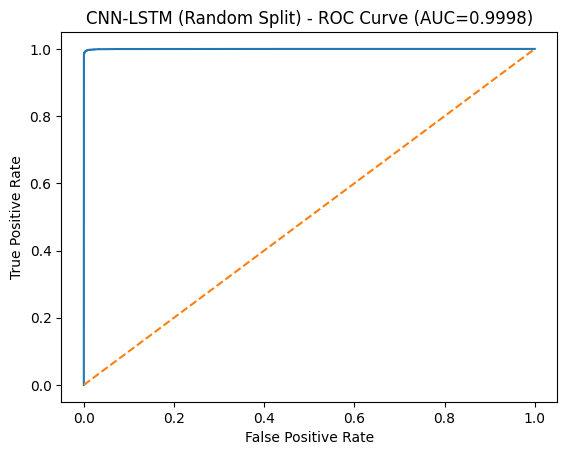

In [22]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve

# Safety: make sure arrays are numpy with correct shapes
X_test_seq = np.asarray(X_test_seq, dtype=np.float32)
y_test = np.asarray(y_test, dtype=np.int32).ravel()

# Predict
y_prob = model.predict(X_test_seq, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# Metrics
acc = accuracy_score(y_test, y_pred)
print("CNN-LSTM (Random Split) Accuracy:", acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Save figures folder
os.makedirs("figures", exist_ok=True)

# Confusion matrix plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title("CNN-LSTM (Random Split) - Confusion Matrix")
plt.savefig("figures/cm_random_split.png", dpi=200, bbox_inches="tight")
plt.show()

# ROC curve
auc = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"CNN-LSTM (Random Split) - ROC Curve (AUC={auc:.4f})")
plt.savefig("figures/roc_random_split.png", dpi=200, bbox_inches="tight")
plt.show()


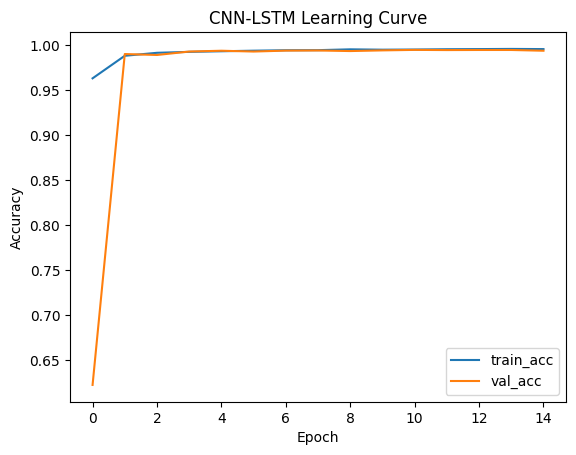

In [23]:
import os
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)

plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN-LSTM Learning Curve")
plt.legend()
plt.savefig("figures/learning_curve.png", dpi=200, bbox_inches="tight")
plt.show()


In [24]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# 1) Column names (NSL-KDD has 41 features + label + difficulty)
cols = [
 "duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment","urgent",
 "hot","num_failed_logins","logged_in","num_compromised","root_shell","su_attempted","num_root",
 "num_file_creations","num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
 "count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
 "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count","dst_host_same_srv_rate",
 "dst_host_diff_srv_rate","dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
 "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"
]

train_path = "/content/KDDTrain+.txt"
test_path  = "/content/KDDTest+.txt"

train_df = pd.read_csv(train_path, header=None, names=cols)
test_df  = pd.read_csv(test_path, header=None, names=cols)

# 2) Binary label (normal vs attack) - robust to "normal" / "normal."
def to_binary(s):
    s = str(s).strip().lower().replace(".", "")
    return 0 if s == "normal" else 1

y_train_full = train_df["label"].apply(to_binary).values.astype(np.int32)
y_test_final = test_df["label"].apply(to_binary).values.astype(np.int32)

# 3) Features (drop label + difficulty)
X_train_raw = train_df.drop(columns=["label","difficulty"])
X_test_raw  = test_df.drop(columns=["label","difficulty"])

# 4) One-hot encode using CONCAT to keep SAME columns
cat_cols = ["protocol_type","service","flag"]
combined = pd.concat([X_train_raw, X_test_raw], axis=0, ignore_index=True)
combined = pd.get_dummies(combined, columns=cat_cols)

X_train = combined.iloc[:len(X_train_raw)].values
X_test  = combined.iloc[len(X_train_raw):].values

# 5) Scale using TRAIN only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 6) Reshape for CNN/LSTM: (samples, features, 1)
X_train_seq = X_train_scaled.astype(np.float32)[:, :, None]
X_test_seq  = X_test_scaled.astype(np.float32)[:, :, None]

# 7) Train/Val split (only inside train set)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_seq, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

# 8) Build CNN-LSTM
def build_cnn_lstm(input_shape):
    m = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv1D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),
        layers.Conv1D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),
        layers.LSTM(64),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ])
    m.compile(optimizer="adam", loss="binary_crossentropy",
              metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])
    return m

model2 = build_cnn_lstm((X_tr.shape[1], 1))

early_stop = callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

history2 = model2.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

# 9) FINAL evaluation on official test set (KDDTest+)
y_prob = model2.predict(X_test_seq, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("\nFINAL RESULTS on KDDTest+ (official test set)")
print("Accuracy:", accuracy_score(y_test_final, y_pred))
print("\nClassification Report:\n", classification_report(y_test_final, y_pred, digits=4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_final, y_pred))

Epoch 1/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 71s 169ms/step - accuracy: 0.9320 - auc: 0.9657 - loss: 0.1967 - val_accuracy: 0.8003 - val_auc: 0.9821 - val_loss: 0.3999
Epoch 2/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 54s 138ms/step - accuracy: 0.9837 - auc: 0.9955 - loss: 0.0553 - val_accuracy: 0.9884 - val_auc: 0.9989 - val_loss: 0.0322
Epoch 3/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 56s 141ms/step - accuracy: 0.9913 - auc: 0.9988 - loss: 0.0281 - val_accuracy: 0.9907 - val_auc: 0.9993 - val_loss: 0.0260
Epoch 4/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 57s 144ms/step - accuracy: 0.9924 - auc: 0.9990 - loss: 0.0247 - val_accuracy: 0.9938 - val_auc: 0.9993 - val_loss: 0.0210
Epoch 5/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 56s 142ms/step - accuracy: 0.9931 - auc: 0.9992 - loss: 0.0222 - val_accuracy: 0.9913 - val_auc: 0.9994 - val_loss: 0.0243
Epoch 6/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 57s 144ms/step - accuracy: 0.9936 - auc: 0.9993 - loss: 0.0202 - val_accuracy: 0.9925 - val_auc: 0.9994 - val_loss: 0.0209
Epoch 7/30
394/394 ━━━

In [25]:
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

# -----------------------------
# 1) Load NSL-KDD files (Train+ and Test+)
# -----------------------------
train_file = "/content/KDDTrain+.txt"
test_file  = "/content/KDDTest+.txt"

columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
    'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
    'root_shell','su_attempted','num_root','num_file_creations','num_shells',
    'num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count',
    'srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate',
    'same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count',
    'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate',
    'label','difficulty'
]

train_df = pd.read_csv(train_file, names=columns)
test_df  = pd.read_csv(test_file,  names=columns)

# Binary label: normal=0, attack=1
train_df["binary_label"] = (train_df["label"] != "normal").astype(int)
test_df["binary_label"]  = (test_df["label"]  != "normal").astype(int)

categorical_cols = ["protocol_type", "service", "flag"]

# -----------------------------
# 2) One-hot encode (fit on train, align test columns)
# -----------------------------
train_enc = pd.get_dummies(train_df, columns=categorical_cols)
test_enc  = pd.get_dummies(test_df,  columns=categorical_cols)

y_train_full = train_enc["binary_label"].values
y_test_final = test_enc["binary_label"].values

X_train_full = train_enc.drop(["label","difficulty","binary_label"], axis=1)
X_test_final = test_enc.drop(["label","difficulty","binary_label"], axis=1)

# Align columns so train/test have identical features
X_test_final = X_test_final.reindex(columns=X_train_full.columns, fill_value=0)

# -----------------------------
# 3) Split TRAIN+ into train/val (for tuning only)
# -----------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

# -----------------------------
# 4) Scale using TRAIN only (important)
# -----------------------------
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test_final)

X_train_s = X_train_s.astype(np.float32)
X_val_s   = X_val_s.astype(np.float32)
X_test_s  = X_test_s.astype(np.float32)

# CNN/LSTM input shape: (samples, timesteps/features, channels)
X_train_seq = X_train_s[..., np.newaxis]
X_val_seq   = X_val_s[..., np.newaxis]
X_test_seq  = X_test_s[..., np.newaxis]

print("Train seq:", X_train_seq.shape, "Val seq:", X_val_seq.shape, "Test seq:", X_test_seq.shape)

# -----------------------------
# 5) Class weights (helps imbalance)
# -----------------------------
classes = np.array([0,1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = {0: weights[0], 1: weights[1]}
print("Class weights:", class_weight)

# -----------------------------
# 6) Build CNN-LSTM model
# -----------------------------
n_features = X_train_seq.shape[1]

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_features, 1)),
    tf.keras.layers.Conv1D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling1D(2),

    tf.keras.layers.Conv1D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling1D(2),

    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc", mode="max", patience=3, restore_best_weights=True
)

history = model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=20,
    batch_size=256,
    callbacks=[early_stop],
    class_weight=class_weight,
    verbose=1
)

# -----------------------------
# 7) FINAL evaluation on official test set (KDDTest+)
# -----------------------------
y_prob = model.predict(X_test_seq).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("\nFINAL RESULTS on KDDTest+ (official test set)")
print("Accuracy:", accuracy_score(y_test_final, y_pred))
print("ROC-AUC :", roc_auc_score(y_test_final, y_prob))
print("\nClassification Report:\n", classification_report(y_test_final, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_final, y_pred))


Train seq: (100778, 122, 1) Val seq: (25195, 122, 1) Test seq: (22544, 122, 1)
Class weights: {0: np.float64(0.9353120243531202), 1: np.float64(1.0743006993006994)}
Epoch 1/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 59s 139ms/step - accuracy: 0.9352 - auc: 0.9677 - loss: 0.1946 - val_accuracy: 0.9363 - val_auc: 0.9875 - val_loss: 0.1705
Epoch 2/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 83s 141ms/step - accuracy: 0.9805 - auc: 0.9906 - loss: 0.0740 - val_accuracy: 0.9832 - val_auc: 0.9981 - val_loss: 0.0387
Epoch 3/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 55s 140ms/step - accuracy: 0.9883 - auc: 0.9982 - loss: 0.0363 - val_accuracy: 0.9875 - val_auc: 0.9982 - val_loss: 0.0396
Epoch 4/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 56s 143ms/step - accuracy: 0.9918 - auc: 0.9988 - loss: 0.0269 - val_accuracy: 0.9544 - val_auc: 0.9918 - val_loss: 0.1583
Epoch 5/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 55s 140ms/step - accuracy: 0.9932 - auc: 0.9989 - loss: 0.0240 - val_accuracy: 0.9875 - val_auc: 0.9992 - val_loss: 0.0357
Epoch 6/20
394/394 ━

In [26]:
print("X_train_seq:", "X_train_seq" in globals())
print("y_train:", "y_train" in globals())
print("X_test_seq:", "X_test_seq" in globals())
print("y_test:", "y_test" in globals())


X_train_seq: True
y_train: True
X_test_seq: True
y_test: True


In [27]:
import numpy as np

X_train_seq = np.asarray(X_train_seq, dtype=np.float32)
X_test_seq  = np.asarray(X_test_seq, dtype=np.float32)
y_train     = np.asarray(y_train, dtype=np.int32)
y_test      = np.asarray(y_test, dtype=np.int32)

print(X_train_seq.shape, X_test_seq.shape, y_train.shape, y_test.shape)


(100778, 122, 1) (22544, 122, 1) (100778,) (25195,)


In [28]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_seq, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Train:", X_tr.shape, y_tr.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test_seq.shape, y_test.shape)

Train: (80622, 122, 1) (80622,)
Val  : (20156, 122, 1) (20156,)
Test : (22544, 122, 1) (25195,)


In [29]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

def build_cnn_lstm(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv1D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),

        layers.Conv1D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),

        layers.LSTM(64),
        layers.Dropout(0.3),

        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
    )
    return model

model = build_cnn_lstm(X_tr.shape[1:])

early_stop = callbacks.EarlyStopping(
    monitor="val_auc", mode="max",
    patience=3, restore_best_weights=True
)

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/30
315/315 ━━━━━━━━━━━━━━━━━━━━ 49s 140ms/step - accuracy: 0.9178 - auc: 0.9561 - loss: 0.2280 - val_accuracy: 0.5394 - val_auc: 0.9176 - val_loss: 1.7431
Epoch 2/30
315/315 ━━━━━━━━━━━━━━━━━━━━ 45s 142ms/step - accuracy: 0.9837 - auc: 0.9981 - loss: 0.0449 - val_accuracy: 0.9732 - val_auc: 0.9970 - val_loss: 0.0778
Epoch 3/30
315/315 ━━━━━━━━━━━━━━━━━━━━ 82s 143ms/step - accuracy: 0.9894 - auc: 0.9987 - loss: 0.0323 - val_accuracy: 0.9862 - val_auc: 0.9984 - val_loss: 0.0389
Epoch 4/30
315/315 ━━━━━━━━━━━━━━━━━━━━ 81s 139ms/step - accuracy: 0.9918 - auc: 0.9990 - loss: 0.0266 - val_accuracy: 0.9866 - val_auc: 0.9987 - val_loss: 0.0384
Epoch 5/30
315/315 ━━━━━━━━━━━━━━━━━━━━ 82s 140ms/step - accuracy: 0.9922 - auc: 0.9992 - loss: 0.0233 - val_accuracy: 0.9882 - val_auc: 0.9990 - val_loss: 0.0306
Epoch 6/30
315/315 ━━━━━━━━━━━━━━━━━━━━ 84s 145ms/step - accuracy: 0.9933 - auc: 0.9993 - loss: 0.0202 - val_accuracy: 0.9940 - val_auc: 0.9997 - val_loss: 0.0181
Epoch 7/30
315/315 ━━━

In [35]:
# Show likely variable names in memory
names = [k for k in globals().keys() if any(s in k.lower() for s in
        ["x_train", "y_train", "x_test", "y_test", "scaled", "final"])]
print(sorted(names))

['X_test', 'X_test_cnn', 'X_test_final', 'X_test_raw', 'X_test_s', 'X_test_scaled', 'X_test_seq', 'X_train', 'X_train_cnn', 'X_train_full', 'X_train_raw', 'X_train_s', 'X_train_scaled', 'X_train_seq', 'y_test', 'y_test_final', 'y_train', 'y_train_full']


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, f1_score

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# ---------------------------
# 1) Load official NSL-KDD files
# ---------------------------
cols = [
 'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent',
 'hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root',
 'num_file_creations','num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login',
 'count','srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate',
 'diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count','dst_host_same_srv_rate',
 'dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
 'dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate',
 'label','difficulty'
]

train_path = "/content/KDDTrain+.txt"
test_path  = "/content/KDDTest+.txt"

df_tr = pd.read_csv(train_path, header=None, names=cols)
df_te = pd.read_csv(test_path,  header=None, names=cols)

# drop difficulty column
df_tr = df_tr.drop(columns=["difficulty"])
df_te = df_te.drop(columns=["difficulty"])

# binary labels: normal=0, attack=1
y_train_full = (df_tr["label"] != "normal").astype(int).values
y_test_final = (df_te["label"] != "normal").astype(int).values

X_tr_raw = df_tr.drop(columns=["label"])
X_te_raw = df_te.drop(columns=["label"])

# ---------------------------
# 2) One-hot encode categorical + align columns
# ---------------------------
cat_cols = ["protocol_type", "service", "flag"]
X_tr_enc = pd.get_dummies(X_tr_raw, columns=cat_cols)
X_te_enc = pd.get_dummies(X_te_raw, columns=cat_cols)

# align test to train columns
X_te_enc = X_te_enc.reindex(columns=X_tr_enc.columns, fill_value=0)

# ---------------------------
# 3) Scale (fit on train only)
# ---------------------------
scaler = StandardScaler()
X_train_full_scaled = scaler.fit_transform(X_tr_enc)
X_test_final_scaled  = scaler.transform(X_te_enc)

print("Full train:", X_train_full_scaled.shape, y_train_full.shape)
print("Official test:", X_test_final_scaled.shape, y_test_final.shape)

# ---------------------------
# 4) Create VALIDATION split from FULL TRAIN (not from test)
# ---------------------------
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full_scaled, y_train_full,
    test_size=0.2, random_state=42, stratify=y_train_full
)

# reshape for CNN-LSTM: (samples, timesteps/features, channels)
X_tr_seq   = X_tr[..., np.newaxis]
X_val_seq  = X_val[..., np.newaxis]
X_test_seq = X_test_final_scaled[..., np.newaxis]

print("Shapes check:")
print("X_tr_seq:", X_tr_seq.shape, "y_tr:", y_tr.shape)
print("X_val_seq:", X_val_seq.shape, "y_val:", y_val.shape)
print("X_test_seq:", X_test_seq.shape, "y_test_final:", y_test_final.shape)

# ---------------------------
# 5) Build CNN-LSTM (clean)
# ---------------------------
tf.random.set_seed(42)

model = models.Sequential([
    layers.Input(shape=(X_tr_seq.shape[1], 1)),
    layers.Conv1D(64, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),

    layers.Conv1D(32, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),

    layers.LSTM(64),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

early_stop = callbacks.EarlyStopping(
    monitor="val_auc", mode="max", patience=3, restore_best_weights=True
)

history = model.fit(
    X_tr_seq, y_tr,
    validation_data=(X_val_seq, y_val),
    epochs=20,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

# ---------------------------
# 6) Threshold tuning (THIS WILL NOW WORK)
# ---------------------------
val_prob = model.predict(X_val_seq, verbose=0).ravel()
ths = np.linspace(0.05, 0.95, 181)
f1s = [f1_score(y_val, (val_prob >= t).astype(int)) for t in ths]
best_thr = ths[int(np.argmax(f1s))]

print("\nBest threshold (from validation):", best_thr)
print("Best val F1:", max(f1s))

# ---------------------------
# 7) Final evaluation on OFFICIAL TEST SET (KDDTest+)
# ---------------------------
test_prob = model.predict(X_test_seq, verbose=0).ravel()
y_pred = (test_prob >= best_thr).astype(int)

print("\nFINAL RESULTS on KDDTest+ (official test set)")
print("Accuracy:", accuracy_score(y_test_final, y_pred))
print("ROC-AUC :", roc_auc_score(y_test_final, test_prob))
print("\nClassification report:\n", classification_report(y_test_final, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test_final, y_pred))


Full train: (125973, 122) (125973,)
Official test: (22544, 122) (22544,)
Shapes check:
X_tr_seq: (100778, 122, 1) y_tr: (100778,)
X_val_seq: (25195, 122, 1) y_val: (25195,)
X_test_seq: (22544, 122, 1) y_test_final: (22544,)
Epoch 1/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 63s 149ms/step - accuracy: 0.9370 - auc: 0.9682 - loss: 0.1945 - val_accuracy: 0.8736 - val_auc: 0.9882 - val_loss: 0.4065
Epoch 2/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 80s 145ms/step - accuracy: 0.9865 - auc: 0.9979 - loss: 0.0405 - val_accuracy: 0.9858 - val_auc: 0.9993 - val_loss: 0.0364
Epoch 3/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 55s 139ms/step - accuracy: 0.9903 - auc: 0.9988 - loss: 0.0303 - val_accuracy: 0.9902 - val_auc: 0.9991 - val_loss: 0.0286
Epoch 4/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 55s 140ms/step - accuracy: 0.9924 - auc: 0.9991 - loss: 0.0233 - val_accuracy: 0.9937 - val_auc: 0.9993 - val_loss: 0.0189
Epoch 5/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 56s 142ms/step - accuracy: 0.9931 - auc: 0.9991 - loss: 0.0221 - val_accuracy: 0.992